# Algoritmo de Construcción Iterativa de Modelos mediante Regresión Simbólica (PySR)

Este notebook implementa la **versión 0.2** del algoritmo iterativo para encontrar una ecuación matemática que describa la **Energía de Enlace Nuclear (BE)**, comparándolo con el modelo teórico **MISR**.

**Cambios respecto a la versión anterior (Algoritmo 0.1):**
- 🔵 El conjunto de **entrenamiento se restringe a núcleos con Z ≤ 50**, mientras que la comparación final se realiza sobre el dataset completo.
- 🔵 Se aumentó el subconjunto de variables a `s = 4`.
- 🔵 Se aumentó la complejidad máxima de SR a `n_t = 40`.
- 🔵 Se usa **MAE** (Error Absoluto Medio) en las comparaciones.
- 🔵 Se corrigió la fórmula de la **ecuación MISR**.
- 🔵 Se mejoró la **visualización**: 4 paneles con LaTeX y tabla de configuración.

---

## Pseudocódigo del Algoritmo

```
CONSTRUCCIÓN ITERATIVA DEL MODELO:
  Mientras iteración ≤ max_iter Y ratio_mejora ≥ θ:
    1. Realizar división de datos en k grupos (k-fold) sobre el conjunto de entrenamiento (Z ≤ 50).
    2. Usar Árboles de Decisión Potenciados (BDT) y Regresión de Información Mutua
       en los datos de entrenamiento para evaluar la importancia de las variables.
    3. Para cada grupo (fold):
       a. Seleccionar un subconjunto de variables X_sub de tamaño s basado en las
          puntuaciones de importancia.
       b. Realizar Regresión Simbólica (SR) con n_t términos en X_sub para predecir Y.
       c. Almacenar las ecuaciones de mejor rendimiento basadas en evaluación multiobjetivo.
    4. Seleccionar la mejor ecuación de entre todos los grupos.
    5. Actualizar Y para que sean los residuos del mejor modelo actual.
    6. Incrementar iteración.

FINALIZACIÓN DEL MODELO:
  Sumar las ecuaciones de cada iteración para formar el modelo final y propagar incertidumbres.

COMPARACIÓN:
  Evaluar el modelo PySR y la ecuación MISR sobre el dataset COMPLETO (todos los Z).
```

---

## Resumen de Implementación vs. Algoritmo

| Paso del Algoritmo | Estado | Comentario |
|---|---|---|
| División k-fold sobre entrenamiento (Z ≤ 50) | ✅ Implementado | `KFold` con `n_splits=5` sobre núcleos Z ≤ 50 |
| Árboles de Decisión Potenciados (BDT) para importancia | ✅ Implementado | `GradientBoostingRegressor` |
| Regresión de Información Mutua para importancia | ❌ **No implementado** | Solo BDT; falta `mutual_info_regression` |
| Seleccionar subconjunto X_sub de tamaño s | ✅ Implementado | `s=4` variables más importantes |
| Regresión Simbólica con n_t términos | ✅ Implementado | PySR con `maxsize=40` |
| Evaluación multiobjetivo | ⚠️ Parcial | Solo primer término de la perdida |
| Seleccionar mejor ecuación entre folds | ✅ Implementado |  |
| Actualizar Y a residuos | ✅ Implementado | `y = y - y_pred_global` |
| Condición de parada (ratio_mejora ≥ θ) | ✅ Implementado | `theta=0.05` |
| Sumar ecuaciones para modelo final | ✅ Implementado | Suma simbólica con sympy |
| Propagación de incertidumbres | ❌ **No implementado** | Falta propagación formal de errores |
| Optimización de hiperparámetros con validación | ❌ **No implementado** | Parámetros fijados manualmente |


---

## 0. Importación de Librerías

Se importan las librerías necesarias:

- **`pandas`**: manipulación de datos tabulares.
- **`numpy`**: cálculo numérico vectorizado.
- **`pathlib.Path`**: construcción de rutas de archivo multiplataforma.
- **`sklearn.model_selection.KFold`**: validación cruzada k-fold (paso 1 del algoritmo).
- **`sklearn.ensemble.GradientBoostingRegressor`**: BDT para evaluar importancia de variables (paso 2).
- **`pysr.PySRRegressor`**: motor de regresión simbólica (paso 3b).
- **`matplotlib.pyplot`**: visualización de resultados.
- **`sympy`**: manipulación simbólica para simplificar la ecuación final.


In [1]:
"""
ALGORITMO DE CONSTRUCCIÓN ITERATIVA DE MODELOS MEDIANTE REGRESIÓN SIMBÓLICA (PySR)
Propósito: Encontrar una ecuación matemática que describa la Energía de Enlace (BE)
comparándolo con el modelo teórico MISR. Versión: 0.2

Versión 0.2:
- El set de entrenamiento se redujo solo para Z <= 50
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.ensemble import GradientBoostingRegressor
from pysr import PySRRegressor
import matplotlib.pyplot as plt
import sympy as sp
import textwrap
from pathlib import Path

[juliapkg] Found dependencies: c:\users\kaleth\appdata\local\python\pythoncore-3.14-64\lib\site-packages\juliacall\juliapkg.json
[juliapkg] Found dependencies: c:\users\kaleth\appdata\local\python\pythoncore-3.14-64\lib\site-packages\juliapkg\juliapkg.json
[juliapkg] Found dependencies: c:\users\kaleth\appdata\local\python\pythoncore-3.14-64\lib\site-packages\pysr\juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] Using Julia 1.11.9 at C:\Users\Kaleth\.julia\environments\pyjuliapkg\pyjuliapkg\install\bin\julia.exe
[juliapkg] Using Julia project at C:\Users\Kaleth\.julia\environments\pyjuliapkg
[juliapkg] Writing Project.toml:
           | [deps]
           | PythonCall = "6099a3de-0909-46bc-b1f4-468b9a2dfc0d"
           | OpenSSL_jll = "458c3c95-2e84-50aa-8efc-19380b2a3a95"
           | SymbolicRegression = "8254be44-1295-4e6a-a16d-46603ac705cb"
           | Serialization = "9e88b

---

## 1. Carga y Preprocesamiento de Datos

Este paso **no aparece explícitamente en el pseudocódigo**, pero es un prerrequisito fundamental.

### ¿Qué se hace aquí?

1. **Carga del CSV** `be_exp.csv` con datos experimentales de núcleos atómicos (Z, N, BE, etc.).
2. **Limpieza**: Conversión de columnas a numérico, eliminación de filas con `NaN`.
3. **Filtro por Z ≤ 50** *(nuevo en v0.2)*: Se separa el dataset completo (`dataset_full`) del dataset de entrenamiento (`dataset`) restringido a núcleos ligeros.
4. **Feature Engineering** — Variables físicas derivadas:
   - **A** = Z + N → Número de masa total
   - **BEpA** = BE / A → Energía de enlace por nucleón
   - **I** = (N − Z) / A → Isospin relativo
   - **P** = (nn × np) / (nn + np) → Factor de Casten *(calculado en `dataset_full` pero NO usado como feature en v0.2)*
5. **Definición de X e Y**:
   - **X** (características): `Z, N, A, I, nn, np` — 6 variables
   - **Y** (variable objetivo): `BE`
6. **Pesos**: $w_i = \frac{1}{1 + \sigma_i}$ — inversamente proporcionales a la incertidumbre experimental.

> ⚠️ **Diferencia clave con v0.1**: En esta versión el entrenamiento se realiza **exclusivamente sobre núcleos con Z ≤ 50**, mientras que la evaluación final se hace sobre el dataset completo (`dataset_full`). Esto permite evaluar la capacidad de **extrapolación** del modelo hacia núcleos pesados.


In [2]:
# =============================================================================
# 1. CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================
directorio_script = Path(".").resolve()
ruta_dataset = directorio_script / "be_exp.csv"

dataset = pd.read_csv(ruta_dataset)

# Limpieza: Asegurar que las columnas sean numéricas y eliminar valores nulos.
for col in dataset.columns:
    if col != 'spinAndParity':
        dataset[col] = pd.to_numeric(dataset[col], errors='coerce')

dataset = dataset.dropna()

# =============================================================================
# FILTRO: Entrenar solo con núcleos Z <= 50
# =============================================================================
dataset_full = dataset.copy()          # Copia completa para comparación final
dataset = dataset[dataset['Z'] <= 50].reset_index(drop=True)
print(f"\n[FILTRO] Entrenamiento restringido a Z <= 50: {len(dataset)} núcleos (de {len(dataset_full)} totales)")

# Creación de variables físicas para el dataset COMPLETO
dataset_full['A']    = dataset_full['Z'] + dataset_full['N']
dataset_full['BEpA'] = dataset_full['BE'] / dataset_full['A']
dataset_full['I']    = (dataset_full['N'] - dataset_full['Z']) / dataset_full['A']
dataset_full['P']    = (dataset_full['nn'] * dataset_full['np']) / (dataset_full['nn'] + dataset_full['np'])

# Creación de variables físicas para el dataset de entrenamiento (Z <= 50)
dataset['A']    = dataset['Z'] + dataset['N']
dataset['BEpA'] = dataset['BE'] / dataset['A']
dataset['I']    = (dataset['N'] - dataset['Z']) / dataset['A']
dataset['P']    = (dataset['nn'] * dataset['np']) / (dataset['nn'] + dataset['np'])

print("\nDataset de entrenamiento con nuevas variables (A, BEpA, I, P):")
print(dataset[['Z', 'N', 'A', 'BE', 'BEpA', 'I', 'nn', 'np', 'P']].head())


[FILTRO] Entrenamiento restringido a Z <= 50: 1948 núcleos (de 4685 totales)

Dataset de entrenamiento con nuevas variables (A, BEpA, I, P):
   Z   N   A      BE   BEpA         I  nn  np         P
0  9  18  27  185.76  6.880  0.333333  20   8  5.714286
1  9  18  27  185.76  6.880  0.333333  20   8  5.714286
2  9  18  27  185.76  6.880  0.333333  20   8  5.714286
3  9  18  27  185.76  6.880  0.333333  20   8  5.714286
4  9  16  25  183.40  7.336  0.280000  20   8  5.714286


---

## 2. Definición de Variables y Configuración de Hiperparámetros

En esta versión, **todo el conjunto Z ≤ 50 se usa para el bucle iterativo** con K-Fold interno. La evaluación externa se realiza sobre `dataset_full`.

### Hiperparámetros de PySR.

| Parámetro | Valor | Descripción |
|-----------|-------|-------------|
| `n_splits` (k) | 5 | Número de grupos para K-Fold |
| `s` | **4** | Tamaño del subconjunto de variables X_sub |
| `n_t` | **40** | Complejidad máxima SR |
| `max_iter` | 1 | Iteraciones máximas del bucle while |
| `theta` (θ) | 0.05 | Ratio de mejora mínimo para continuar |
| `niterations` | 20 | Iteraciones internas de PySR |
| `ncycles_per_iter` | 2000 | Ciclos por iteración PySR |
| `maxdepth` | 10 | Profundidad máxima del árbol simbólico |
| `parsimony` | 0.0001 | Penalización por complejidad |
| `binary_ops` | +, -, *, / | Operadores binarios basicos |
| `unary_ops` | square, sqrt, cbrt, inv | Se añaden `cbrt` e `inv` *(nuevo en v0.2)* |

> ⚠️ **Lo que falta del algoritmo:** La **optimización opcional de hiperparámetros** que ajustaría automáticamente estos valores usando un conjunto de validación.


In [3]:
# =============================================================================
# 2. DEFINICIÓN DE VARIABLES Y CONFIGURACIÓN DE HIPERPARÁMETROS
# =============================================================================

# Definición de características (X) y variable objetivo (y)
# NOTA v0.2: Se eliminó la variable P (Factor de Casten) respecto a v0.1
X = dataset[['Z', 'N', 'A', 'I', 'nn', 'np']]
y = dataset['BE']

# Sigma experimental → Pesos
sigma_exp = dataset['bindingEnergyUncertainty'] if 'bindingEnergyUncertainty' in dataset.columns else 0.0
pesos = 1.0 / (1.0 + sigma_exp)

# Configuración del K-Fold
# En v0.2 todo el set Z <= 50 se usa para entrenamiento con validación cruzada interna.
n_splits = 5
X_train_cv     = X.reset_index(drop=True)
y_train_cv     = y.reset_index(drop=True)
pesos_train_cv = pesos.reset_index(drop=True)

kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

s   = 4    # Tamaño del subconjunto de variables a seleccionar
n_t = 40   # Complejidad máxima en SR (maxsize)

# ── Parámetros de PySRRegressor centralizados (v0.2) ─────────────────────
niterations       = 20
ncycles_per_iter  = 2000
maxdepth          = 10
parsimony         = 0.0001
random_state_pysr = 11
binary_ops        = ["+", "-", "*", "/"]
unary_ops         = ["square", "sqrt", "cbrt", "inv"]

# Variables del bucle while principal
max_iter     = 1
theta        = 0.05
iteracion    = 1
ratio_mejora = 1.0
mse_anterior = float('inf')

modelos_finales = []  # Almacena la ecuación ganadora de cada iteración

print("Configuración completada.")
print(f"  Dataset entrenamiento: {len(X)} núcleos (Z <= 50)")
print(f"  Variables (X): {list(X.columns)}")
print(f"  s={s}, n_t={n_t}, max_iter={max_iter}, theta={theta}")
print(f"  PySR: niterations={niterations}, ncycles={ncycles_per_iter}, maxdepth={maxdepth}")

Configuración completada.
  Dataset entrenamiento: 1948 núcleos (Z <= 50)
  Variables (X): ['Z', 'N', 'A', 'I', 'nn', 'np']
  s=4, n_t=40, max_iter=1, theta=0.05
  PySR: niterations=20, ncycles=2000, maxdepth=10


---

## 3. Bucle Principal — Construcción Iterativa del Modelo

Este es el **núcleo del algoritmo**. Corresponde directamente al bloque `while` del pseudocódigo.

### Flujo de cada iteración

```
┌─────────────────────────────────────────────────────┐
│  ITERACIÓN i                                        │
│                                                     │
│  Para cada fold k:                                  │
│    ┌───────────────────────────────────────┐        │
│    │ 1. GradientBoosting → Importancias    │ ← BDT  │
│    │ 2. Seleccionar top-s variables        │        │
│    │ 3. PySR en X_sub → Ecuación simbólica │ ← SR   │
│    │ 4. Evaluar MSE en validación          │        │
│    └───────────────────────────────────────┘        │
│                                                     │
│  Seleccionar mejor ecuación (menor MSE global)      │
│  Y ← Y - predicción(mejor_modelo)  [residuos]       │
│  Calcular ratio_mejora                              │
└─────────────────────────────────────────────────────┘
```

### Detalles importantes de la implementación

**Paso 2 — Evaluación de importancia de variables:**
- ✅ `GradientBoostingRegressor` para `feature_importances_`.
- ❌ **Falta**: `mutual_info_regression` (Regresión de Información Mutua). El algoritmo original indica usar **ambos** métodos.

**Paso 3 — Regresión Simbólica (PySR) — Cambios en v0.2:**
- Operadores binarios: `+, -, *, /`*
- Operadores unarios: `square, sqrt, cbrt, inv`
- Restricciones: `square`, `sqrt`, `cbrt` no pueden anidarse a sí mismos.
- Función de pérdida: `loss(prediction, target, weight) = (weight * (prediction - target))²`
- Parámetros centralizados al inicio de la celda anterior.

> **Nota sobre renombrado de columnas**: PySR no acepta `N` e `I` como nombres de variable porque coinciden con símbolos reservados. Por eso `N` → `Neut` e `I` → `Iso`.


In [4]:
# =============================================================================
# 3. BUCLE PRINCIPAL — CONSTRUCCIÓN ITERATIVA DEL MODELO
# =============================================================================

print(f"\nIniciando Construcción Iterativa del Modelo...")
while iteracion <= max_iter and ratio_mejora >= theta:
    print(f"\n==========================================")
    print(f" ITERACIÓN {iteracion}")
    print(f"==========================================")

    mejores_ecuaciones = []

    print(f"\nRealizando K-Folding y Regresión Simbólica:")
    for fold, (train_index, val_index) in enumerate(kf.split(X_train_cv)):
        X_train, X_val = X_train_cv.iloc[train_index], X_train_cv.iloc[val_index]
        y_train, y_val = y_train_cv.iloc[train_index], y_train_cv.iloc[val_index]
        pesos_train    = pesos_train_cv.iloc[train_index]

        # ── Paso 2: Importancia de variables con BDT ─────────────────────────
        gbr = GradientBoostingRegressor(random_state=42)
        gbr.fit(X_train, y_train)
        importancias   = pd.Series(gbr.feature_importances_, index=X.columns).sort_values(ascending=False)
        vars_seleccionadas = importancias.head(s).index.tolist()

        X_sub_train = X_train[vars_seleccionadas]

        print(f"\n--- Fold {fold+1} ---")
        print(f"Variables seleccionadas: {vars_seleccionadas}")

        # ── Paso 3: Regresión Simbólica con PySR ─────────────────────────────
        X_sub_train_pysr = X_sub_train.rename(columns={'N': 'Neut', 'I': 'Iso'})
        X_unidades       = ["" for _ in vars_seleccionadas]

        model = PySRRegressor(
            # ── Operadores Disponibles ──────────────────
            binary_operators=binary_ops,
            unary_operators=unary_ops,

            # ── Parámetros de la Búsqueda ───────────────
            niterations=niterations,
            ncycles_per_iteration=ncycles_per_iter,
            maxsize=n_t,
            maxdepth=maxdepth,

            # ── Restricciones de Complejidad ────────────
            constraints={
                "square": 1,
                "cbrt":   1,
                "sqrt":   1,
            },
            nested_constraints={
                "square": {"square": 0},
                "cbrt":   {"cbrt":   0},
                "sqrt":   {"sqrt":   0},
            },

            # ── Pérdida y Penalizaciones ────────────────
            elementwise_loss="loss(prediction, target, weight) = (weight * (prediction - target))^2",
            parsimony=parsimony,
            complexity_of_variables=1,
            complexity_of_constants=1,
            dimensional_constraint_penalty=10**5,

            # ── Configuración de Ejecución ──────────────
            random_state=random_state_pysr,
            deterministic=True,
            parallelism='serial',
            verbosity=0,
            progress=True,
        )

        try:
            model.fit(
                X_sub_train_pysr,
                y_train,
                weights=pesos_train,
                X_units=X_unidades,
                y_units="Constants.MeV"
            )

            # Evaluación en validación interna
            X_sub_val_pysr = X_val[vars_seleccionadas].rename(columns={'N': 'Neut', 'I': 'Iso'})
            y_pred_val     = model.predict(X_sub_val_pysr)
            mse_val        = np.mean((y_val - y_pred_val)**2)

            mejor_ecuacion = str(model.sympy())
            mejores_ecuaciones.append({
                'fold':      fold + 1,
                'variables': vars_seleccionadas,
                'ecuacion':  mejor_ecuacion,
                'mse_val':   mse_val,
                'model':     model
            })
            print(f"Mejor Ecuación Fold {fold+1}: {mejor_ecuacion} (MSE Val: {mse_val:.4f})")
        except Exception as e:
            print(f"Error en Regresión Simbólica en Fold {fold+1}: {e}")

    # ── Resumen de la iteración ───────────────────────────────────────────
    print(f"\n--- Modelos de Mejor Rendimiento Almacenados en Iteración {iteracion} ---")
    for r in mejores_ecuaciones:
        print(f"Fold {r['fold']}: [Vars: {r['variables']}] -> {r['ecuacion']} (MSE Val: {r['mse_val']:.4f})")

    # ── Selección del mejor modelo global y actualización de Y ──────────
    if mejores_ecuaciones:
        mejor_resultado_global = min(mejores_ecuaciones, key=lambda x: x['mse_val'])
        print(f"\n[!] Mejor ecuación global: Fold {mejor_resultado_global['fold']} — MSE {mejor_resultado_global['mse_val']:.4f}")

        mejor_modelo = mejor_resultado_global['model']
        vars_optimas = mejor_resultado_global['variables']

        modelos_finales.append({
            'iteracion': iteracion,
            'ecuacion':  mejor_resultado_global['ecuacion'],
            'model':     mejor_modelo,
            'variables': vars_optimas,
            'mse_val':   mejor_resultado_global['mse_val']
        })

        # Ratio de mejora
        if mse_anterior != float('inf') and mse_anterior > 0:
            ratio_mejora = (mse_anterior - mejor_resultado_global['mse_val']) / mse_anterior
            print(f"Ratio de mejora respecto a iteración anterior: {ratio_mejora:.4f}")

        mse_anterior = mejor_resultado_global['mse_val']

        # Actualizar Y → residuos del mejor modelo actual
        X_global_sub = X[vars_optimas].rename(columns={'N': 'Neut', 'I': 'Iso'})
        y_pred_global = mejor_modelo.predict(X_global_sub)
        y = y - y_pred_global

        print("\nVariable Y actualizada a los residuos del mejor modelo.")
        print("Primeros 5 valores de los nuevos residuos (Y):")
        print(y.head())
    else:
        print("\n[!] No se encontraron ecuaciones válidas en esta iteración. Abortando.")
        break

    iteracion += 1


Iniciando Construcción Iterativa del Modelo...

 ITERACIÓN 1

Realizando K-Folding y Regresión Simbólica:

--- Fold 1 ---
Variables seleccionadas: ['A', 'Z', 'I', 'N']


c:\Users\Kaleth\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Mejor Ecuación Fold 1: (Z**2/(-Neut - 1.9909984) + (-Z - 2.1756856)/(-0.5012043) - 63.171604/Z)*10.35847/0.69013685 (MSE Val: 17.6226)

--- Fold 2 ---
Variables seleccionadas: ['A', 'Z', 'I', 'N']


c:\Users\Kaleth\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Mejor Ecuación Fold 2: (Z - 3.5450244)*(-15.0516128426321*A/Neut + 42.4249816197418 + 38.0318128986151/sqrt(Z)) (MSE Val: 8.7370)

--- Fold 3 ---
Variables seleccionadas: ['A', 'Z', 'I', 'N']


...

Mejor Ecuación Fold 3: -17.072256*A + 11.105797*Neut + 251.73248 - 553.32410898432/(Abs(Z)**(1/3)*sign(Z)) + 75.08006*Neut*Z/A (MSE Val: 20.2392)

--- Fold 4 ---
Variables seleccionadas: ['A', 'Z', 'I', 'np']


c:\Users\Kaleth\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Mejor Ecuación Fold 4: (A + 6.490716*Abs(Iso)**(1/3)*sign(Iso) + 5.490716*Abs(Z)**(1/3)*sign(Z))*(-0.016251938*sqrt(A) - 0.016251938*Abs(Z)**(1/3)*sign(Z) + 7.8996325 - 32.509308/Z) (MSE Val: 88.5414)

--- Fold 5 ---
Variables seleccionadas: ['A', 'Z', 'I', 'N']


c:\Users\Kaleth\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Mejor Ecuación Fold 5: (A - Neut*(Iso*6.8921795*Iso - 2.0454702))*4.1329494 (MSE Val: 53.6829)

--- Modelos de Mejor Rendimiento Almacenados en Iteración 1 ---
Fold 1: [Vars: ['A', 'Z', 'I', 'N']] -> (Z**2/(-Neut - 1.9909984) + (-Z - 2.1756856)/(-0.5012043) - 63.171604/Z)*10.35847/0.69013685 (MSE Val: 17.6226)
Fold 2: [Vars: ['A', 'Z', 'I', 'N']] -> (Z - 3.5450244)*(-15.0516128426321*A/Neut + 42.4249816197418 + 38.0318128986151/sqrt(Z)) (MSE Val: 8.7370)
Fold 3: [Vars: ['A', 'Z', 'I', 'N']] -> -17.072256*A + 11.105797*Neut + 251.73248 - 553.32410898432/(Abs(Z)**(1/3)*sign(Z)) + 75.08006*Neut*Z/A (MSE Val: 20.2392)
Fold 4: [Vars: ['A', 'Z', 'I', 'np']] -> (A + 6.490716*Abs(Iso)**(1/3)*sign(Iso) + 5.490716*Abs(Z)**(1/3)*sign(Z))*(-0.016251938*sqrt(A) - 0.016251938*Abs(Z)**(1/3)*sign(Z) + 7.8996325 - 32.509308/Z) (MSE Val: 88.5414)
Fold 5: [Vars: ['A', 'Z', 'I', 'N']] -> (A - Neut*(Iso*6.8921795*Iso - 2.0454702))*4.1329494 (MSE Val: 53.6829)

[!] Mejor ecuación global: Fold 2 — MSE 8.7370

---

## 4. Finalización del Modelo

### Correspondencia con el Algoritmo

### ¿Qué se hace?

1. ✅ **Suma de ecuaciones**: Se recopilan las ecuaciones simbólicas (sympy) de cada iteración y se suman:
   $$\text{Modelo Final} = \sum_{i=1}^{n} f_i(X)$$

2. ✅ **Simplificación**: Se usa `sp.simplify()` y se redondean coeficientes a 2 decimales.

3. ❌ **Propagación de incertidumbres**: **No implementada**. El modelo final suma ecuaciones sin propagar errores formalmente.


In [5]:
# =============================================================================
# 4. FINALIZACIÓN DEL MODELO
# =============================================================================
print("\n==========================================")
print(" FINALIZACIÓN DEL MODELO")
print("==========================================")
print("Ecuaciones seleccionadas en cada iteración:")

ecuaciones_sympy = []
for m in modelos_finales:
    print(f"Iteración {m['iteracion']}: {m['ecuacion']} (Vars: {m['variables']})")
    ecuaciones_sympy.append(m['model'].sympy())

try:
    ecuacion_total_sympy  = sum(ecuaciones_sympy)
    ecuacion_simplificada = sp.simplify(ecuacion_total_sympy)

    # Redondear coeficientes flotantes a 2 decimales
    ecuacion_redondeada = ecuacion_simplificada.xreplace(
        {n: sp.Float(round(float(n), 2))
         for n in ecuacion_simplificada.atoms(sp.Number)
         if isinstance(n, sp.Float)}
    )
    modelo_creado_simplificado_str = str(ecuacion_redondeada)

    # Generar versión LaTeX para el gráfico
    # Si la ecuación es Piecewise, extraer solo el caso general (el último)
    if isinstance(ecuacion_redondeada, sp.Piecewise):
        ecuacion_para_latex = ecuacion_redondeada.args[-1][0]
    else:
        ecuacion_para_latex = ecuacion_redondeada

    ecuacion_latex = sp.latex(ecuacion_para_latex)

    # Embellecer nombres de variables
    replacements = {"Neut": "N", "Iso": "I", "nn": "n_n", "np": "n_p"}
    for old, new in replacements.items():
        ecuacion_latex = ecuacion_latex.replace(old, new)

    print(f"\nModelo Final Sumado y Simplificado:\n{modelo_creado_simplificado_str}")
    print(f"\nEcuación LaTeX:\n{ecuacion_latex}")

except Exception as e:
    print(f"Error al simplificar con sympy: {e}")
    modelo_creado_simplificado_str = " + ".join([f"({m['ecuacion']})" for m in modelos_finales])
    ecuacion_latex = (
        modelo_creado_simplificado_str
        .replace("Neut", "N").replace("Iso", "I")
        .replace("nn", "n_n").replace("np", "n_p")
        .replace("*", "\\cdot ")
    )
    print(f"\nModelo Final Sumado:\n{modelo_creado_simplificado_str}")


 FINALIZACIÓN DEL MODELO
Ecuaciones seleccionadas en cada iteración:
Iteración 1: (Z - 3.5450244)*(-15.0516128426321*A/Neut + 42.4249816197418 + 38.0318128986151/sqrt(Z)) (Vars: ['A', 'Z', 'I', 'N'])

Modelo Final Sumado y Simplificado:
(Z - 3.55)*(-15.05*A/Neut + 42.42 + 38.03/sqrt(Z))

Ecuación LaTeX:
\left(Z - 3.55\right) \left(- \frac{15.05 A}{N} + 42.42 + \frac{38.03}{\sqrt{Z}}\right)


---

## 5. Comparación con el Modelo MISR Teórico

Esta sección **no forma parte del algoritmo original**, sino que es una validación adicional.

### Diferencias clave respecto a v0.1

| Aspecto | v0.1 | v0.2 |
|---------|------|------|
| Dataset de comparación | Dataset de entrenamiento (mismo Z ≤ 50) | **Dataset completo** (todos los Z) |
| Métrica | MSE | **MAE** |

### Ecuación MISR (v0.2)

$$BE_{MISR} = \eta_0 Z \left(1 + \frac{1}{N} - \frac{a N}{Z^2}\right) \left[I \left(b - \frac{A^{1/3} N}{Z}\right) + c\right]$$

Con los parámetros:
- $a = 1.10$, $b = 32.43$, $c = 16.70$, $\eta_0 = 1.0 \text{MeV}$

### Métrica usada

$$MAE = \frac{1}{n} \sum_{i=1}^{n} |BE_{real,i} - BE_{pred,i}|$$


In [6]:
# =============================================================================
# 5. COMPARACIÓN CON ECUACIÓN MISR TEÓRICA
# =============================================================================
print("\n==========================================")
print(" COMPARACIÓN CON ECUACIÓN MISR TEÓRICA")
print("==========================================")

# Parámetros ajustados de MISR (v0.2)
a_misr  =  1.10
b_misr  = 32.43
c_misr  = 16.70
eta_0   =  1.0

# Variables del dataset COMPLETO (todos los Z)
Z_total  = dataset_full['Z']
N_total  = dataset_full['N']
A_total  = dataset_full['A']
I_total  = dataset_full['I']
BE_real  = dataset_full['BE']

# ── Cálculo de BE_MISR ────────────────────────────────────────────────────
# BE = eta_0 * Z * (1 + 1/N - a*N/Z^2) * [I*(b - A^{1/3}*N/Z) + c]
termino_par = 1 + 1/N_total - (a_misr * N_total) / (Z_total**2)
termino_bra = I_total * (b_misr - (A_total**(1/3) * N_total) / Z_total) + c_misr
BE_MISR     = eta_0 * Z_total * termino_par * termino_bra

# ── Predicción total del modelo iterativo PySR ───────────────────────────
BE_PySR = np.zeros(len(dataset_full))
for m in modelos_finales:
    vars_opt = m['variables']
    X_sub    = dataset_full[vars_opt].rename(columns={'N': 'Neut', 'I': 'Iso'})
    BE_PySR += m['model'].predict(X_sub)

# ── Métricas ─────────────────────────────────────────────────────────────
mae_pysr = np.mean(np.abs(BE_real - BE_PySR))
mae_misr = np.mean(np.abs(BE_real - BE_MISR))

print(f"MAE Modelo PySR (Total Iterativo): {mae_pysr:.4f} MeV")
print(f"MAE Ecuación MISR:                 {mae_misr:.4f} MeV")


 COMPARACIÓN CON ECUACIÓN MISR TEÓRICA
MAE Modelo PySR (Total Iterativo): 42.4563 MeV
MAE Ecuación MISR:                 66.6530 MeV


---

## 6. Visualización — Gráfico Comparativo (4 Paneles)

### Cambios respecto a v0.1

En v0.1 se generaban **2 paneles**. En v0.2 se generan **4 paneles**:

1. **Predicción vs. Dato Experimental** — Scatter plot en el eje $BE_{exp}$ vs $BE_{pred}$. Los puntos ideales caen sobre la diagonal $y = x$.
2. **Residuos por Nucleón vs Z** *(nuevo)* — Muestra $\Delta BE / A$ en función del número atómico. La línea vertical en $Z = 50$ marca el límite del entrenamiento, permitiendo evaluar extrapolación.
3. **Residuos absolutos vs N** *(nuevo)* — Muestra $\Delta BE$ en función del número de neutrones.
4. **Tabla de parámetros de configuración** *(nuevo)* — Resumen automático de todos los hiperparámetros usados en la ejecución.

Además, el **título principal** ahora muestra la ecuación en formato LaTeX usando el motor MathText de Matplotlib (compatible sin LaTeX instalado).



Generando gráfico comparativo (4 paneles)...

[OK] Gráfico exportado como 'comparacion_misr_pysr_v02.png'


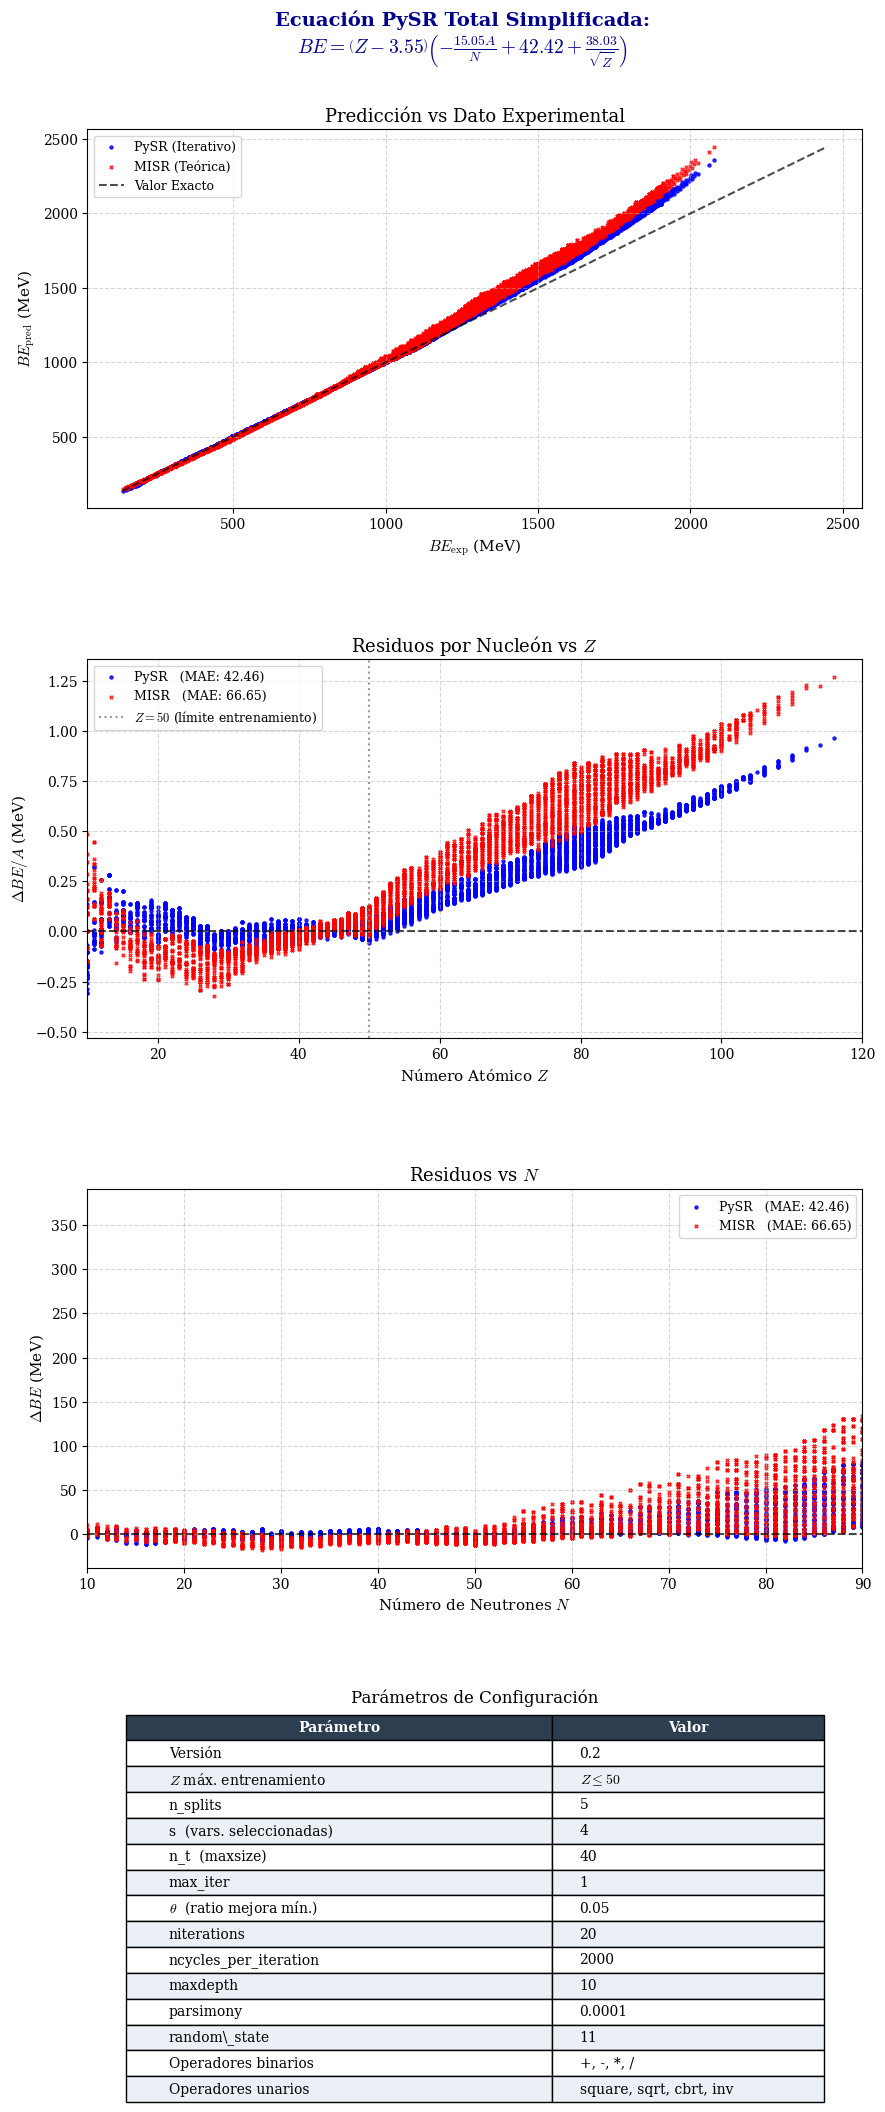

In [7]:
# =============================================================================
# 6. VISUALIZACIÓN — GRÁFICO COMPARATIVO (4 PANELES)
# =============================================================================
print("\nGenerando gráfico comparativo (4 paneles)...")

plt.rcParams.update({
    "text.usetex":       False,
    "font.family":       "serif",
    "mathtext.fontset":  "cm",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "legend.fontsize":    9,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
})

fig = plt.figure(figsize=(10, 24))
plt.subplots_adjust(top=0.93, hspace=0.40)

# Título con ecuación en LaTeX
try:
    plt.suptitle(
        r"Ecuación PySR Total Simplificada:" + "\n" + rf"$BE = {ecuacion_latex}$",
        fontsize=14, color='darkblue', fontweight='bold'
    )
except Exception:
    plt.suptitle(
        f"Ecuación PySR Total Simplificada:\nBE = {modelo_creado_simplificado_str[:100]}...",
        fontsize=12, color='darkblue', fontweight='bold'
    )

# ── Panel 1: Predicciones vs Reales ──────────────────────────────────────
ax1 = plt.subplot(4, 1, 1)
ax1.scatter(BE_real, BE_PySR, alpha=0.8, label=r'PySR (Iterativo)', color='blue',  s=5)
ax1.scatter(BE_real, BE_MISR, alpha=0.8, label=r'MISR (Teórica)',   color='red',   marker='x', s=5)

min_val = min(BE_real.min(), BE_PySR.min(), BE_MISR.min())
max_val = max(BE_real.max(), BE_PySR.max(), BE_MISR.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7, label=r'Valor Exacto')

ax1.set_xlabel(r'$BE_{\mathrm{exp}}$ (MeV)')
ax1.set_ylabel(r'$BE_{\mathrm{pred}}$ (MeV)')
ax1.set_title(r'Predicción vs Dato Experimental')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# ── Panel 2: Residuos por nucleón vs Z ───────────────────────────────────
ax2 = plt.subplot(4, 1, 2)
residuos_pysr_pA = (BE_PySR - BE_real) / A_total
residuos_misr_pA = (BE_MISR - BE_real) / A_total

ax2.scatter(Z_total, residuos_pysr_pA, alpha=0.8, label=rf'PySR   (MAE: {mae_pysr:.2f})', color='blue', s=5)
ax2.scatter(Z_total, residuos_misr_pA, alpha=0.8, label=rf'MISR   (MAE: {mae_misr:.2f})', color='red',  marker='x', s=5)
ax2.axhline(0, color='k', linestyle='--', alpha=0.7)
ax2.axvline(50, color='gray', linestyle=':', linewidth=1.5, alpha=0.8,
            label=r'$Z = 50$ (límite entrenamiento)')

ax2.set_xlim(10, 120)
ax2.set_xlabel(r'Número Atómico $Z$')
ax2.set_ylabel(r'$\Delta BE / A$ (MeV)')
ax2.set_title(r'Residuos por Nucleón vs $Z$')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

# ── Panel 3: Residuos absolutos vs N ─────────────────────────────────────
ax3 = plt.subplot(4, 1, 3)
residuos_pysr_N = BE_PySR - BE_real
residuos_misr_N = BE_MISR - BE_real

ax3.scatter(N_total, residuos_pysr_N, alpha=0.8, label=rf'PySR   (MAE: {mae_pysr:.2f})', color='blue', s=5)
ax3.scatter(N_total, residuos_misr_N, alpha=0.8, label=rf'MISR   (MAE: {mae_misr:.2f})', color='red',  marker='x', s=5)
ax3.axhline(0, color='k', linestyle='--', alpha=0.7)

ax3.set_xlim(10, 90)
ax3.set_xlabel(r'Número de Neutrones $N$')
ax3.set_ylabel(r'$\Delta BE$ (MeV)')
ax3.set_title(r'Residuos vs $N$')
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.5)

# ── Panel 4: Tabla de parámetros de configuración ────────────────────────
ax4 = plt.subplot(4, 1, 4)
ax4.axis('off')

config_params = [
    [r"Versión",                         r"0.2"],
    [r"$Z$ máx. entrenamiento",           r"$Z \leq 50$"],
    [r"n_splits",                         str(n_splits)],
    [r"s  (vars. seleccionadas)",         str(s)],
    [r"n_t  (maxsize)",                   str(n_t)],
    [r"max_iter",                         str(max_iter)],
    [r"$\theta$  (ratio mejora mín.)",    str(theta)],
    [r"niterations",                      str(niterations)],
    [r"ncycles_per_iteration",            str(ncycles_per_iter)],
    [r"maxdepth",                         str(maxdepth)],
    [r"parsimony",                        str(parsimony)],
    [r"random\_state",                    str(random_state_pysr)],
    [r"Operadores binarios",              ", ".join(binary_ops)],
    [r"Operadores unarios",               ", ".join(unary_ops)],
]

table = ax4.table(
    cellText=config_params,
    colLabels=[r"Parámetro", r"Valor"],
    cellLoc='left',
    loc='center',
    colWidths=[0.55, 0.35],
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.55)

for col in range(2):
    table[(0, col)].set_facecolor('#2c3e50')
    table[(0, col)].set_text_props(color='white', fontweight='bold')

for row in range(1, len(config_params) + 1):
    fc = '#eaf0f6' if row % 2 == 0 else 'white'
    for col in range(2):
        table[(row, col)].set_facecolor(fc)

ax4.set_title(r'Parámetros de Configuración', fontsize=12, pad=12)

plt.savefig('comparacion_misr_pysr_v02.png', dpi=300, bbox_inches='tight')
print("\n[OK] Gráfico exportado como 'comparacion_misr_pysr_v02.png'")
plt.show()

---

## 7. Resumen Final: Estado de Implementación vs. Algoritmo

### ✅ Implementado en v0.2

1. **Filtro Z ≤ 50** para el entrenamiento, con comparación sobre el dataset completo.
2. **Centralización de parámetros PySR** al inicio del notebook (tabla de configuración automática).
3. **Corrección de la ecuación MISR** (factorización y signo de $a$).
4. **Cambio de métrica** de MSE a MAE para la comparación final.
5. **4 paneles de visualización** con LaTeX, residuos por nucleón vs Z, residuos vs N, y tabla de configuración.
6. **Nuevos operadores unarios**: `cbrt` e `inv` en PySR.

### ❌ Pendiente (trabajo futuro)

1. **Regresión de Información Mutua** (Paso 2 del algoritmo).
2. **Evaluación multiobjetivo** para almacenamiento de ecuaciones (Paso 3c).
3. **Propagación formal de incertidumbres** (Finalización del modelo).
4. **Optimización automática de hiperparámetros** usando un conjunto de validación.
